# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [13]:
import numpy as np
import pandas as pd
import os
import sklearn
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("data/temps.csv")
df

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41
...,...,...,...,...,...,...,...,...,...
343,2016,12,27,Tues,42,42,45.2,47,47
344,2016,12,28,Wed,42,47,45.3,48,58
345,2016,12,29,Thurs,47,48,45.3,48,65
346,2016,12,30,Fri,48,48,45.4,57,42


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 25.8 KB


In [10]:
df.describe()

,year,month,day,temp_2,temp_1,average,actual,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,95.000000


In [ ]:
# vamos a ver cositas del target

df['actual'].value_counts()

actual
57    16
60    16
68    16
65    13
55    12
71    12
52    11
59    11
64    11
67    11
51    10
77    10
49     9
63     9
76     9
66     9
75     9
48     8
54     8
53     8
61     8
73     8
56     7
58     7
74     7
40     6
62     6
81     6
79     6
69     5
80     5
72     5
45     4
44     4
50     4
46     4
85     4
70     4
41     3
82     3
42     3
39     3
47     2
87     2
78     2
83     2
35     2
89     1
92     1
86     1
88     1
90     1
84     1
36     1
43     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribución de la temperatura máxima (actual)')

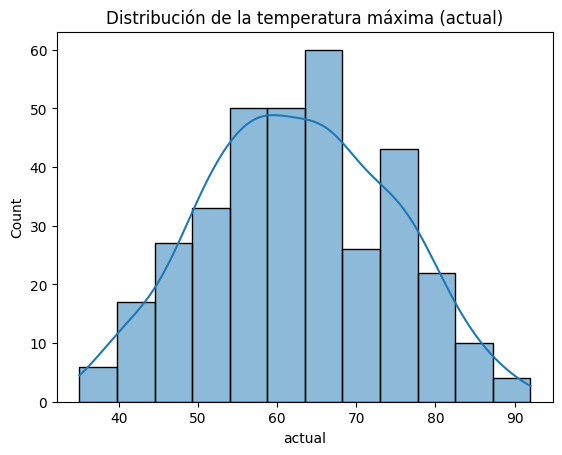

In [ ]:
# voy a ver si el modelo tendrá que lidiar con colas, asimetrías, etc
sns.histplot(df['actual'], kde=True)
plt.title("Distribución de la temperatura máxima (actual)")


# pico claro entre 60-70
# simétrica

<Axes: xlabel='friend', ylabel='actual'>

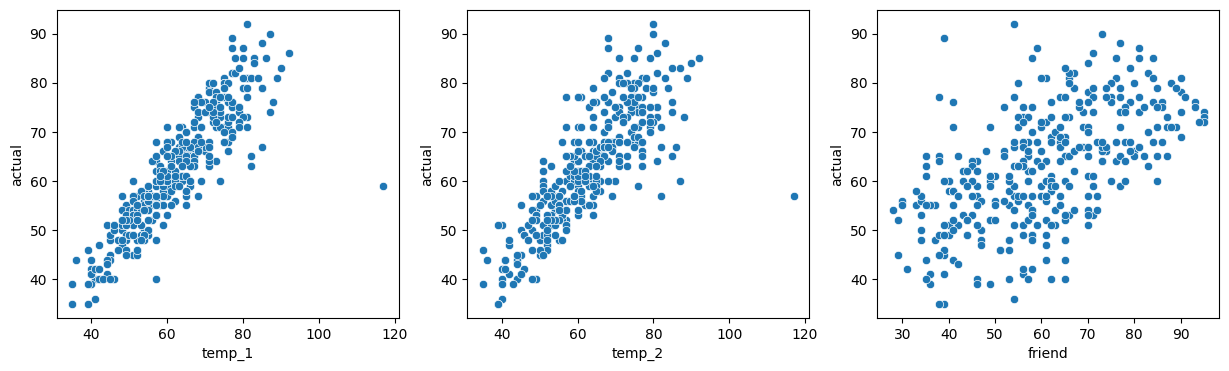

In [ ]:
# relación de 'actual' con cada predictor
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x='temp_1', y='actual', ax=axes[0])
sns.scatterplot(data=df, x='temp_2', y='actual', ax=axes[1])
sns.scatterplot(data=df, x='friend', y='actual', ax=axes[2])


# scatter 1:
# relación casi lineal y muy fuerte
# cuanto más alta fue la temperatura de ayer, más alta es hoy

# scatter 2:
# relación fuerte, aunque algo más dispersa que la anterior
# no tan bueno como el anterior scatter

# scatter 3:
# lo del amigo chapas se ve bastante más disperso, mete bastante ruido

Text(0.5, 1.0, 'Temperatura por día de la semana')

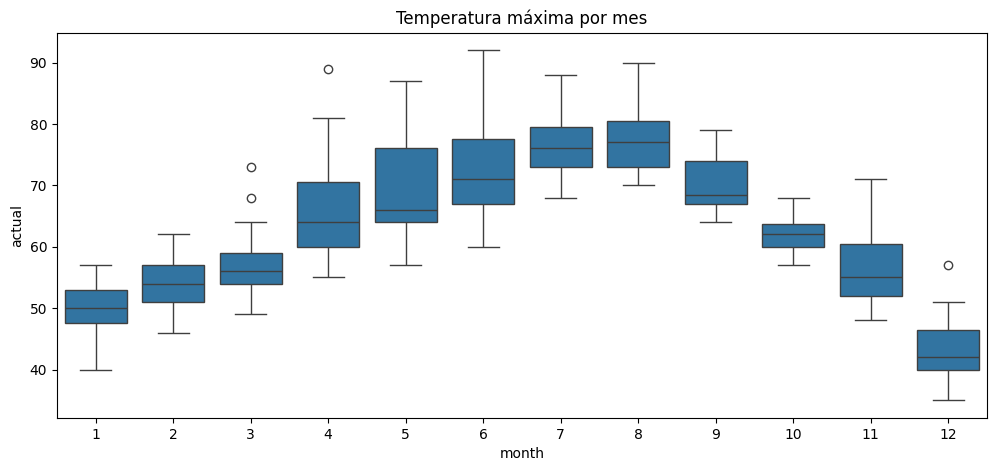

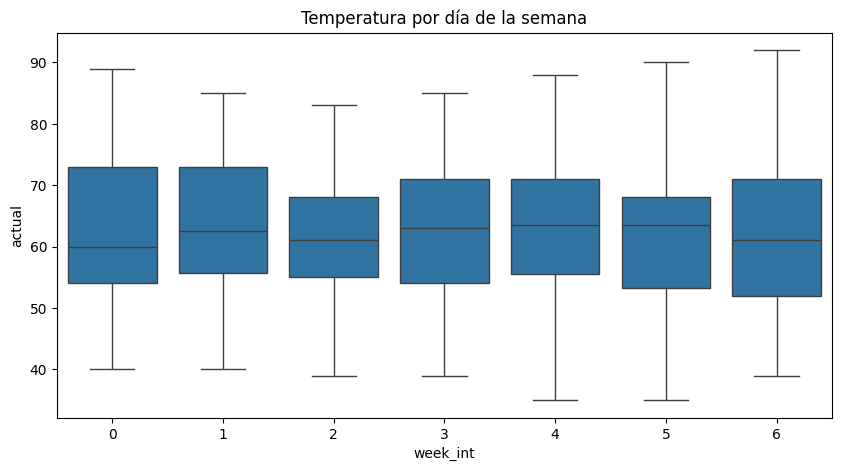

In [ ]:
# voy a ver la estacionalidad y ver si hay patrones por mes, día...

# mes
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='month', y='actual')
plt.title("Temperatura máxima por mes")

# día de la semana
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='week_int', y='actual')
plt.title("Temperatura por día de la semana")



# por día de la semana no se observa ningún patrón, no es significativo

# pero por mes sí se ve un claro patrón 
# de los meses 6 al 8 se ve más temperaturas

In [30]:
df.corr(numeric_only=True)['actual'].sort_values(ascending=False)


actual      1.000000
temp_1      0.877880
average     0.848365
temp_2      0.805835
friend      0.569145
month       0.004529
day        -0.021675
week_int   -0.031188
year             NaN
Name: actual, dtype: float64

In [31]:
# voy a crear una columna con la diferencia entre días

df['dif_temp'] = df['temp_1'] - df['temp_2']


In [32]:
# ahora una con el error del chapas

df['error_chapas'] = df['friend'] - df['average']

In [38]:

df['temp_actual_avg'] = df['actual'] - df['average']


In [39]:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'week_int', 'dif_temp', 'error_chapas', 'temp_actual_avg'],
      dtype='str')

In [35]:
df.head(5)

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_int,dif_temp,error_chapas
0,2016,1,1,Fri,45,45,45.6,45,29,4,0,-16.6
1,2016,1,2,Sat,44,45,45.7,44,61,5,1,15.3
2,2016,1,3,Sun,45,44,45.8,41,56,6,-1,10.2
3,2016,1,4,Mon,44,41,45.9,40,53,0,-3,7.1
4,2016,1,5,Tues,41,40,46.0,44,41,1,-1,-5.0


<Axes: xlabel='error_chapas', ylabel='actual'>

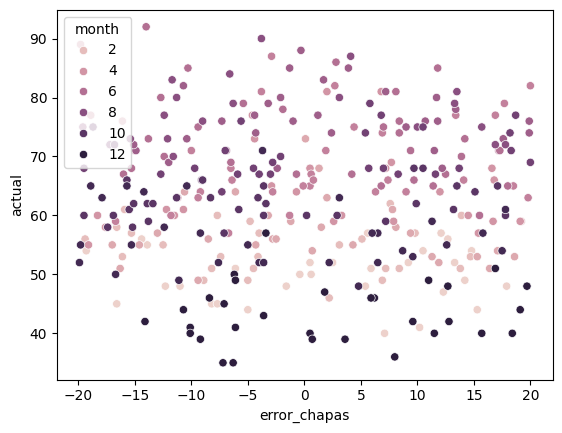

In [36]:
sns.scatterplot(data=df, x='error_chapas', y='actual', hue= 'month')

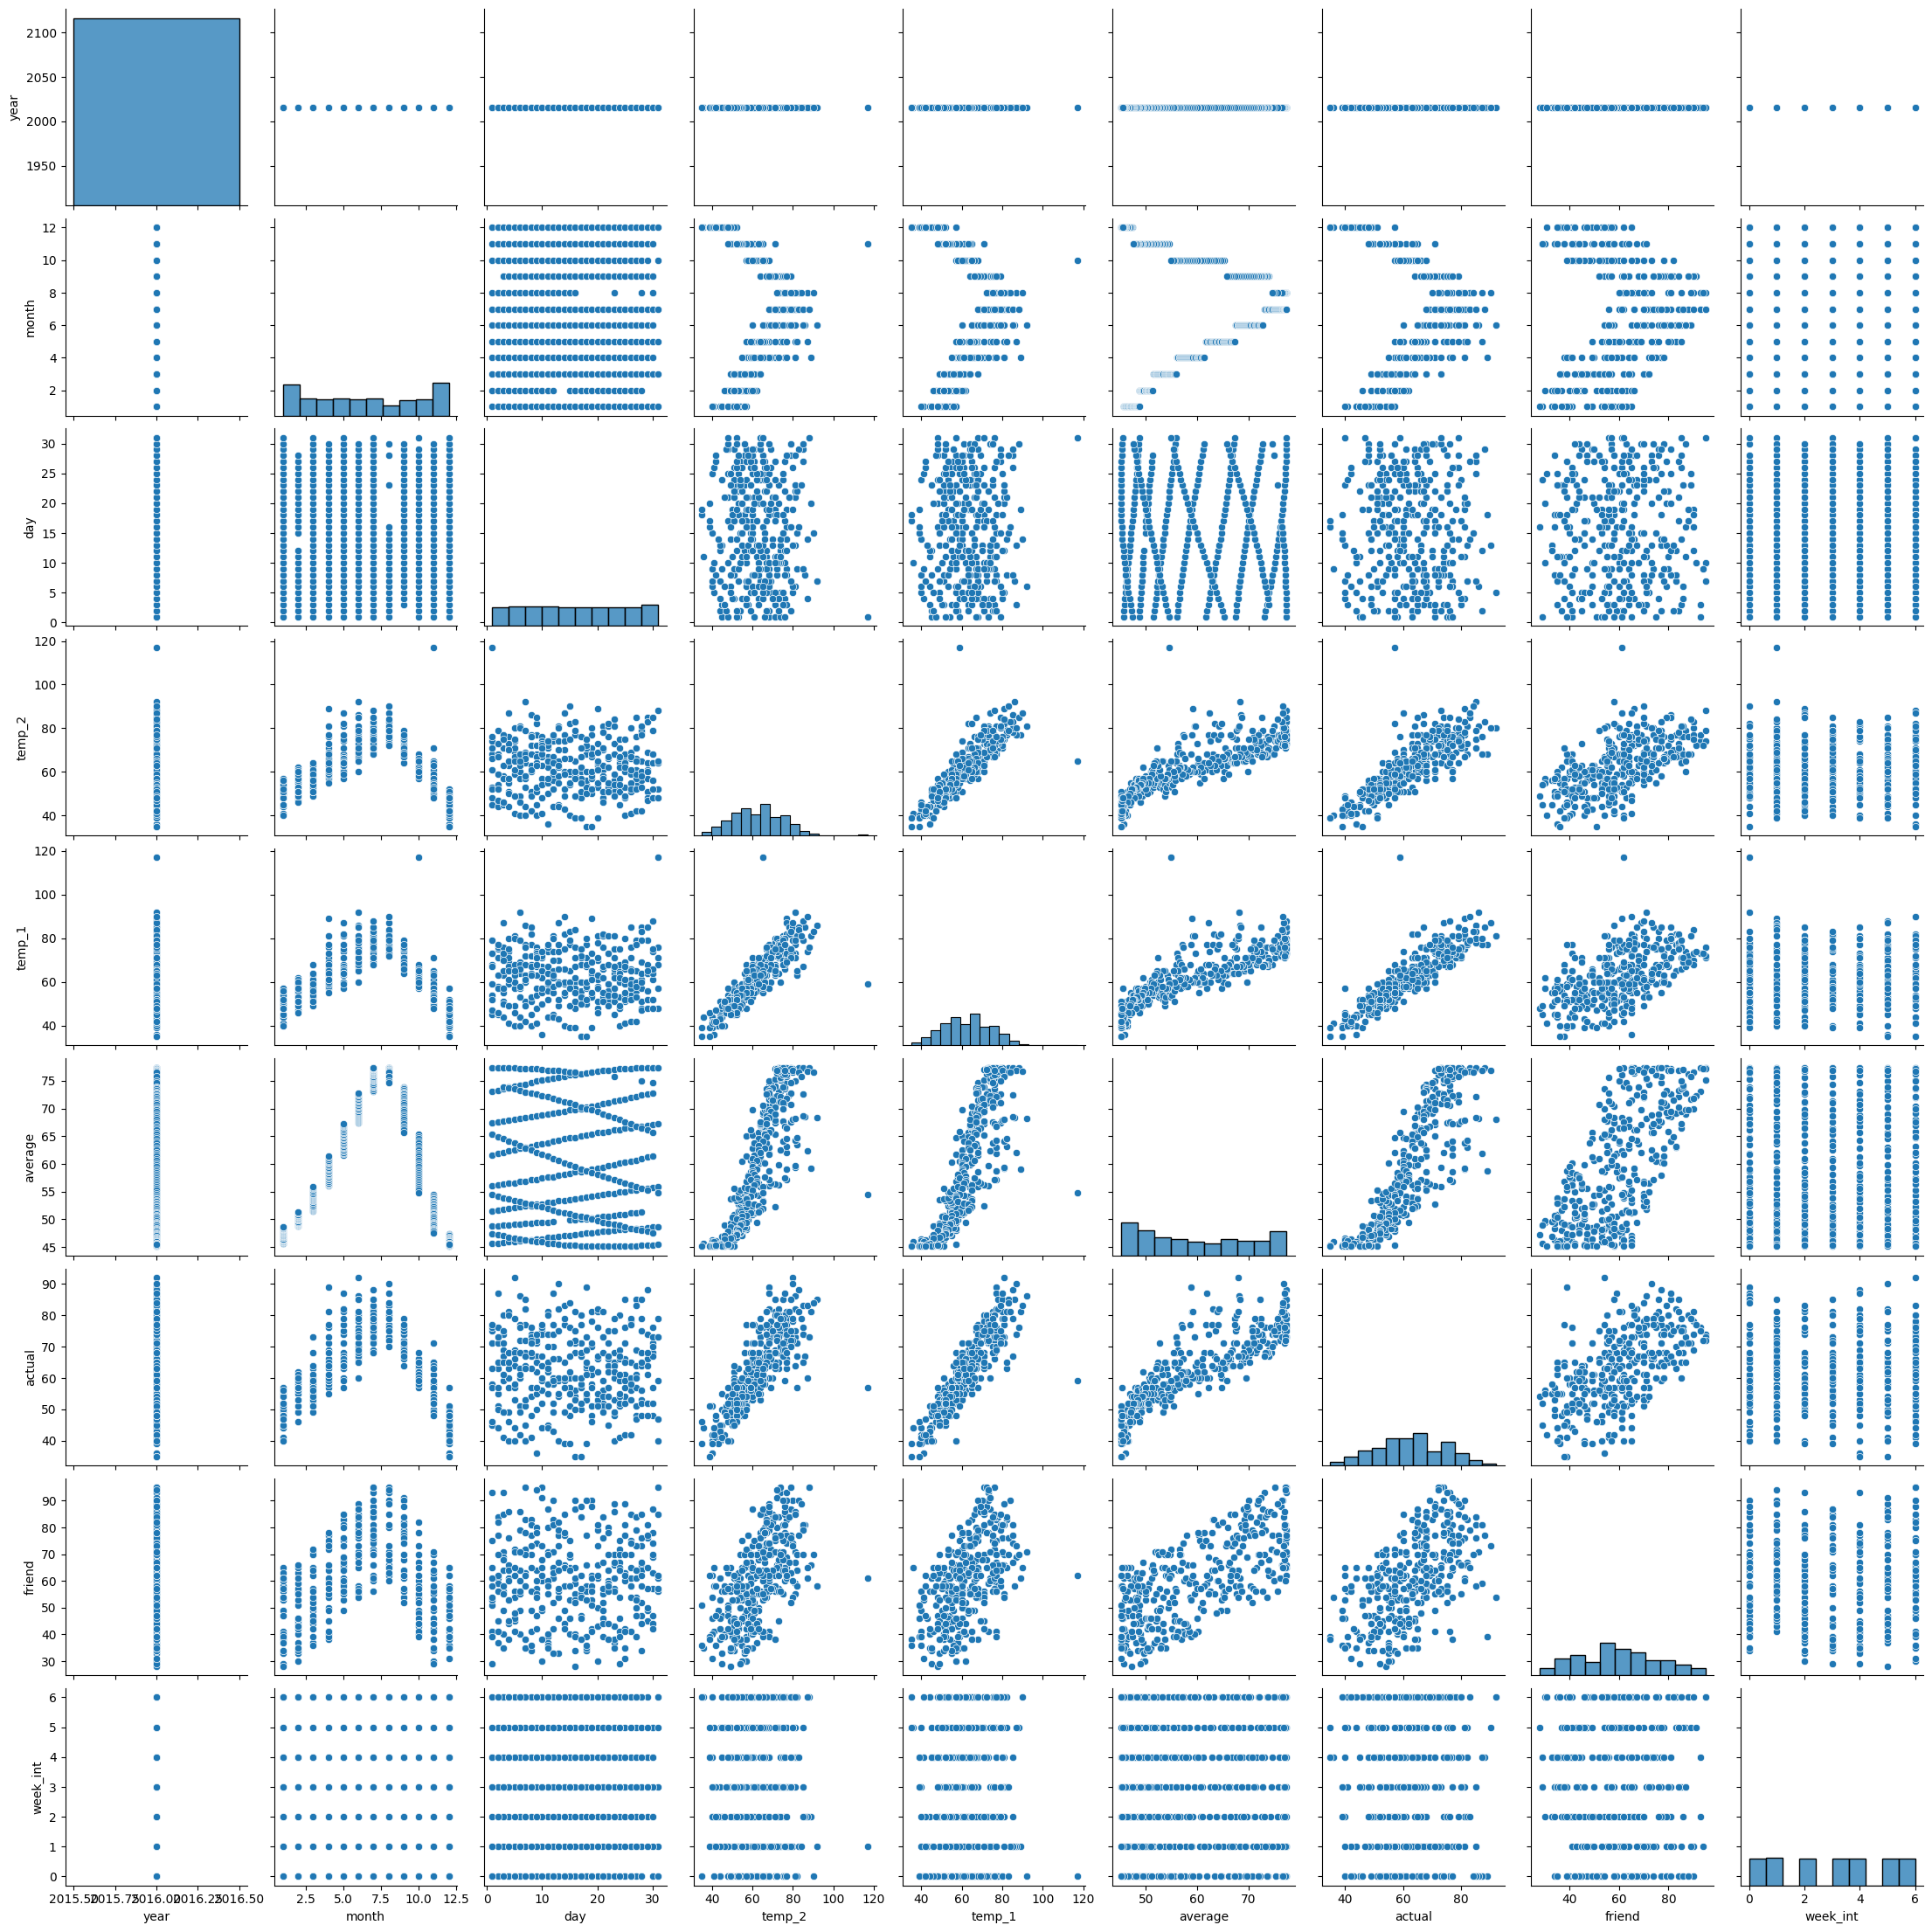

In [26]:
sns.pairplot(df)

<Axes: >

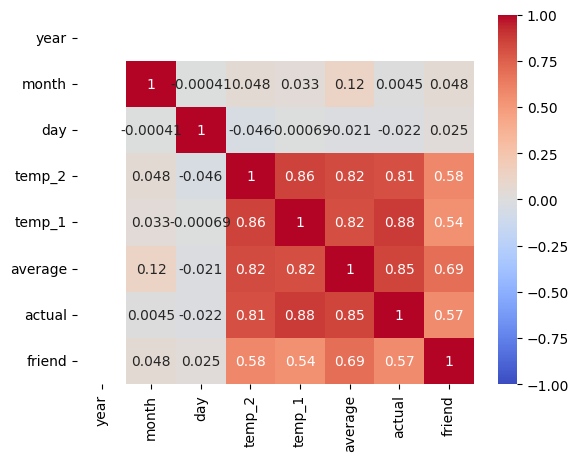

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1)

In [ ]:
# transformo el día de la semana, que está en str, a int
# lunes 0 y domingo 6

# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder() # método para pasar categóricas a numéricas

df['week'].unique()

<ArrowStringArray>
['Fri', 'Sat', 'Sun', 'Mon', 'Tues', 'Wed', 'Thurs']
Length: 7, dtype: str

In [23]:
# voy a hacer un  mapeo mejor porque con LabelEncoder() no puedo controlar que
# lunes sea 0 y domingo sea 6

map_week = {'Mon': 0,
    'Tues': 1,
    'Wed': 2,
    'Thurs': 3,
    'Fri': 4,
    'Sat': 5,
    'Sun': 6}

df['week_int'] = df['week'].map(map_week)

In [24]:
df[['week', 'week_int']].head()

,week,week_int
0,Fri,4
1,Sat,5
2,Sun,6
3,Mon,0
4,Tues,1


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      348 non-null    int64  
 1   month     348 non-null    int64  
 2   day       348 non-null    int64  
 3   week      348 non-null    str    
 4   temp_2    348 non-null    int64  
 5   temp_1    348 non-null    int64  
 6   average   348 non-null    float64
 7   actual    348 non-null    int64  
 8   friend    348 non-null    int64  
 9   week_int  348 non-null    int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 28.5 KB


### 3. Selecciona variables y divide en train y test

In [40]:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'week_int', 'dif_temp', 'error_chapas', 'temp_actual_avg'],
      dtype='str')

In [43]:
from sklearn.model_selection import train_test_split

X = df[['temp_1',
       'temp_2',
       'average',
       'friend',
       'month',
       'dif_temp',
       'temp_actual_avg']]


y = df['actual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 7)
(70, 7)
(278,)
(70,)


### 4. Entrena el modelo


In [44]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=2,
                                  random_state=42)
tree_clf.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
plt.figure(figsize=(10,10))
sklearn.tree.plot_tree(tree_clf,
               feature_names=iris.feature_names[2:],
               class_names=iris.target_names,
               filled = True);

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

### 6. Representa el árbol de decisión

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

### 8. Vuelve a evaluar tu modelo

### 9. Vuelve a representar su árbol

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

### 11. Obten el `feature_importances` de cada variable en el último modelo

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.